# Notebook 01 — Data Extraction
**NST DVA Capstone 2 | Healthcare Sector**

> **Purpose:** Load the raw diabetic patient dataset, perform an initial structural audit, and commit it untouched to `data/raw/`.
>
> ⚠️ **Rule:** This notebook must NEVER modify the source file. Only read and inspect.

---
**Pipeline Stage:** Extract → (Clean) → (Analyze) → (Load)

---

## 1. Environment Setup

In [1]:
# ── Install / upgrade libraries if running in Colab ──────────────────────────
# Uncomment the line below only if running on Google Colab
# !pip install pandas numpy matplotlib seaborn --quiet

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Libraries loaded successfully.')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')

✅ Libraries loaded successfully.
   pandas  : 3.0.2
   numpy   : 2.4.4


## 2. Path Configuration

Update `RAW_DATA_PATH` to point to your raw dataset file.

In [2]:
# ── Path Configuration ────────────────────────────────────────────────────────
# Update this path to match where you placed the raw dataset
RAW_DATA_PATH = '../data/raw/diabetic_data.csv'   # ← change filename if needed

# Verify the file exists before proceeding
if not os.path.exists(RAW_DATA_PATH):
    raise FileNotFoundError(
        f"❌ Raw dataset not found at: {RAW_DATA_PATH}\n"
        "   Please place the CSV in data/raw/ and update RAW_DATA_PATH above."
    )

print(f'✅ Dataset found: {RAW_DATA_PATH}')
print(f'   File size   : {os.path.getsize(RAW_DATA_PATH) / 1_000_000:.2f} MB')

✅ Dataset found: ../data/raw/diabetic_data.csv
   File size   : 19.16 MB


## 3. Load Raw Dataset

In [3]:
# ── Load CSV ──────────────────────────────────────────────────────────────────
# '?' is used as a missing-value marker in this dataset
df_raw = pd.read_csv(RAW_DATA_PATH, na_values=['?', 'Unknown', 'None', ''])

print('✅ Raw dataset loaded.')
print(f'   Rows    : {df_raw.shape[0]:,}')
print(f'   Columns : {df_raw.shape[1]}')

✅ Raw dataset loaded.
   Rows    : 101,766
   Columns : 50


In [4]:
# ── First look ────────────────────────────────────────────────────────────────
print('=== HEAD (first 5 rows) ===')
df_raw.head()

=== HEAD (first 5 rows) ===


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
print('=== TAIL (last 5 rows) ===')
df_raw.tail()

=== TAIL (last 5 rows) ===


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),NaN,1,1,7,6,NaN,NaN,13,3,3,0,0,0,530,530,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


## 4. Schema & Data Types Audit

In [6]:
# ── Column-level audit ────────────────────────────────────────────────────────
audit = pd.DataFrame({
    'dtype'         : df_raw.dtypes,
    'non_null_count': df_raw.count(),
    'null_count'    : df_raw.isnull().sum(),
    'null_pct'      : (df_raw.isnull().mean() * 100).round(2),
    'unique_values' : df_raw.nunique(),
    'sample_value'  : df_raw.iloc[0]
})

print('=== SCHEMA AUDIT ===')
audit

=== SCHEMA AUDIT ===


,dtype,non_null_count,null_count,null_pct,unique_values,sample_value
encounter_id,int64,101766,0,0.00,101766,2278392
patient_nbr,int64,101766,0,0.00,71518,8222157
race,str,99493,2273,2.23,5,Caucasian
gender,str,101766,0,0.00,3,Female
age,str,101766,0,0.00,10,[0-10)
weight,str,3197,98569,96.86,9,NaN
admission_type_id,int64,101766,0,0.00,8,6
discharge_disposition_id,int64,101766,0,0.00,26,25
admission_source_id,int64,101766,0,0.00,17,1
time_in_hospital,int64,101766,0,0.00,14,1


In [7]:
# ── Capstone Gate Check ───────────────────────────────────────────────────────
MIN_ROWS = 5000
MIN_COLS = 8

rows_ok = df_raw.shape[0] >= MIN_ROWS
cols_ok = df_raw.shape[1] >= MIN_COLS

print('=== GATE 1 MINIMUM REQUIREMENTS ===')
print(f'   Row count  : {df_raw.shape[0]:,}  → {"✅ PASS" if rows_ok else "❌ FAIL"} (min {MIN_ROWS:,})')
print(f'   Column count: {df_raw.shape[1]}  → {"✅ PASS" if cols_ok else "❌ FAIL"} (min {MIN_COLS})')

if rows_ok and cols_ok:
    print('\n✅ Dataset meets minimum capstone requirements.')
else:
    print('\n⚠️  Dataset does NOT meet minimum requirements. Please review your dataset.')

=== GATE 1 MINIMUM REQUIREMENTS ===
   Row count  : 101,766  → ✅ PASS (min 5,000)
   Column count: 50  → ✅ PASS (min 8)

✅ Dataset meets minimum capstone requirements.


## 5. Column Inventory & Classification

Classify each column by its analytical role so the cleaning notebook can target them correctly.

In [8]:
# ── Identify numeric vs categorical columns ───────────────────────────────────
numeric_cols     = df_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_raw.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns    ({len(numeric_cols)})  : {numeric_cols}')
print()
print(f'Categorical columns ({len(categorical_cols)})  : {categorical_cols}')

Numeric columns    (13)  : ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical columns (37)  : ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [9]:
# ── Healthcare-specific column groups ─────────────────────────────────────────
# Adjust these lists if your dataset uses different column names

ID_COLS = ['encounter_id', 'patient_nbr']

DEMOGRAPHIC_COLS = ['race', 'gender', 'age', 'weight']

ADMISSION_COLS = [
    'admission_type_id', 'discharge_disposition_id',
    'admission_source_id', 'time_in_hospital',
    'payer_code', 'medical_specialty'
]

UTILIZATION_COLS = [
    'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient'
]

DIAGNOSIS_COLS = ['diag_1', 'diag_2', 'diag_3', 'number_diagnoses']

LAB_COLS = ['max_glu_serum', 'A1Cresult']

MEDICATION_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

CHANGE_COLS   = ['change', 'diabetesMed']
TARGET_COL    = ['readmitted']   # Outcome / target variable

print('✅ Column groups defined.')
print(f'   Medication columns tracked: {len(MEDICATION_COLS)}')

✅ Column groups defined.
   Medication columns tracked: 23


## 6. Missing Value Heatmap

⚠️  9 columns have missing values:

weight              0.97
max_glu_serum       0.95
A1Cresult           0.83
medical_specialty   0.49
payer_code          0.40
race                0.02
diag_3              0.01
diag_2              0.00
diag_1              0.00


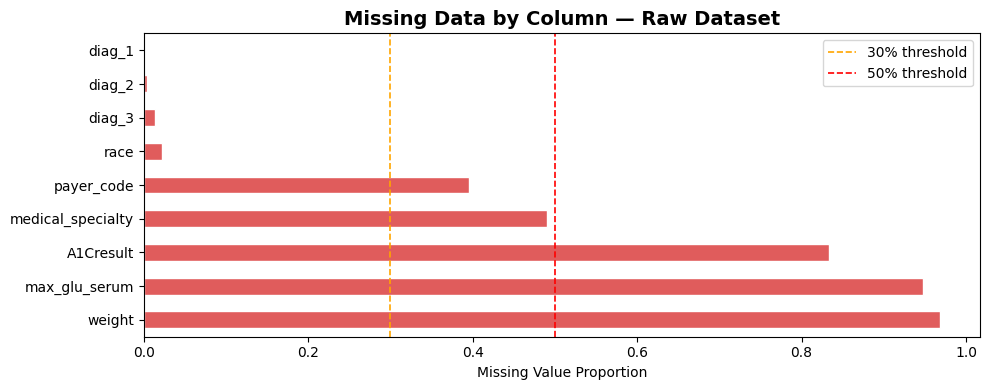

   Chart saved to data/raw/01_missing_heatmap.png


In [10]:
# ── Missing value summary ─────────────────────────────────────────────────────
missing = df_raw.isnull().mean().sort_values(ascending=False)
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print('✅ No missing values detected (after replacing ? with NaN).')
else:
    print(f'⚠️  {len(missing_cols)} columns have missing values:\n')
    print(missing_cols.to_string())

    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_cols) * 0.4)))
    missing_cols.plot(kind='barh', ax=ax, color='#E05C5C', edgecolor='white')
    ax.set_xlabel('Missing Value Proportion')
    ax.set_title('Missing Data by Column — Raw Dataset', fontsize=14, fontweight='bold')
    ax.axvline(0.3, color='orange', linestyle='--', linewidth=1.2, label='30% threshold')
    ax.axvline(0.5, color='red',    linestyle='--', linewidth=1.2, label='50% threshold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../data/raw/01_missing_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('   Chart saved to data/raw/01_missing_heatmap.png')

## 7. Duplicate Record Check

In [11]:
# ── Full-row duplicates ───────────────────────────────────────────────────────
full_dupes = df_raw.duplicated().sum()
print(f'Full-row duplicates       : {full_dupes:,}')

# Duplicate encounter IDs (should be 0 for this dataset)
if 'encounter_id' in df_raw.columns:
    enc_dupes = df_raw['encounter_id'].duplicated().sum()
    print(f'Duplicate encounter_id    : {enc_dupes:,}')

# Patients with multiple encounters — clinically meaningful
if 'patient_nbr' in df_raw.columns:
    multi_enc = df_raw['patient_nbr'].duplicated().sum()
    unique_pts = df_raw['patient_nbr'].nunique()
    total_enc  = len(df_raw)
    print(f'Unique patients           : {unique_pts:,}  (out of {total_enc:,} encounters)')
    print(f'Patients with >1 encounter: {total_enc - unique_pts:,}')
    print('   ℹ️  Multiple encounters per patient are EXPECTED in this dataset.')

Full-row duplicates       : 0
Duplicate encounter_id    : 0
Unique patients           : 71,518  (out of 101,766 encounters)
Patients with >1 encounter: 30,248
   ℹ️  Multiple encounters per patient are EXPECTED in this dataset.


## 8. Target Variable Distribution

=== READMISSION BREAKDOWN ===
      NO  →   54,864  (53.9%)
     >30  →   35,545  (34.9%)
     <30  →   11,357  (11.2%)


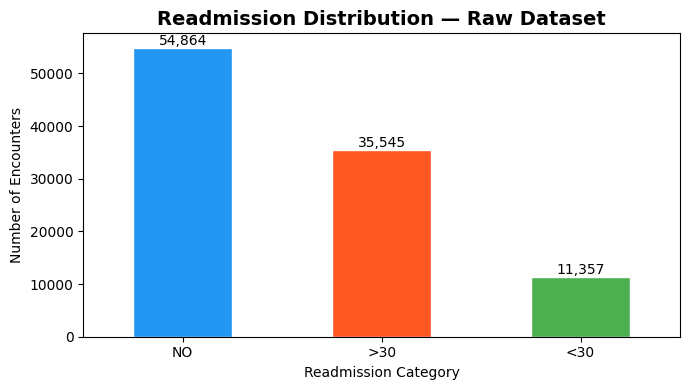

   Chart saved to data/raw/01_readmission_distribution.png


In [12]:
# ── Readmission distribution ──────────────────────────────────────────────────
if 'readmitted' in df_raw.columns:
    readmit_counts = df_raw['readmitted'].value_counts()
    readmit_pct    = df_raw['readmitted'].value_counts(normalize=True) * 100

    print('=== READMISSION BREAKDOWN ===')
    for label in readmit_counts.index:
        print(f'   {label:>5}  →  {readmit_counts[label]:>7,}  ({readmit_pct[label]:.1f}%)')

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ['#2196F3', '#FF5722', '#4CAF50']
    readmit_counts.plot(kind='bar', ax=ax, color=colors[:len(readmit_counts)],
                        edgecolor='white', rot=0)
    ax.set_title('Readmission Distribution — Raw Dataset', fontsize=14, fontweight='bold')
    ax.set_xlabel('Readmission Category')
    ax.set_ylabel('Number of Encounters')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig('../data/raw/01_readmission_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('   Chart saved to data/raw/01_readmission_distribution.png')

## 9. Basic Descriptive Statistics

In [13]:
# ── Numeric summary ───────────────────────────────────────────────────────────
print('=== NUMERIC COLUMNS — DESCRIPTIVE STATISTICS ===')
df_raw[numeric_cols].describe().T

=== NUMERIC COLUMNS — DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.00,165201645.62,102640295.98,12522.00,84961194.00,152388987.00,230270887.50,443867222.00
patient_nbr,101766.00,54330400.69,38696359.35,135.00,23413221.00,45505143.00,87545949.75,189502619.00
admission_type_id,101766.00,2.02,1.45,1.00,1.00,1.00,3.00,8.00
discharge_disposition_id,101766.00,3.72,5.28,1.00,1.00,1.00,4.00,28.00
admission_source_id,101766.00,5.75,4.06,1.00,1.00,7.00,7.00,25.00
time_in_hospital,101766.00,4.40,2.99,1.00,2.00,4.00,6.00,14.00
num_lab_procedures,101766.00,43.10,19.67,1.00,31.00,44.00,57.00,132.00
num_procedures,101766.00,1.34,1.71,0.00,0.00,1.00,2.00,6.00
num_medications,101766.00,16.02,8.13,1.00,10.00,15.00,20.00,81.00
number_outpatient,101766.00,0.37,1.27,0.00,0.00,0.00,0.00,42.00


In [14]:
# ── Categorical top-values ────────────────────────────────────────────────────
print('=== CATEGORICAL COLUMNS — TOP 5 VALUES ===')
for col in categorical_cols[:10]:  # limit to first 10 to keep output manageable
    print(f'\n▸ {col}')
    print(df_raw[col].value_counts().head(5).to_string())

=== CATEGORICAL COLUMNS — TOP 5 VALUES ===

▸ race
race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641

▸ gender
gender
Female             54708
Male               47055
Unknown/Invalid        3

▸ age
age
[70-80)    26068
[60-70)    22483
[50-60)    17256
[80-90)    17197
[40-50)     9685

▸ weight
weight
[75-100)     1336
[50-75)       897
[100-125)     625
[125-150)     145
[25-50)        97

▸ payer_code
payer_code
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532

▸ medical_specialty
medical_specialty
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Surgery-General            3099

▸ diag_1
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508

▸ diag_2
diag_2
276    6752
428    6662
250    6071
427    5036
401    3736

▸ diag_3
diag_3
250    11555
401     8289
276     5175
428     4577
427     3955

▸ m

## 10. Issues Flagged for Cleaning

Document findings here before handing off to Notebook 02.

In [15]:
# ── Extraction summary log ────────────────────────────────────────────────────
print('=' * 60)
print('  EXTRACTION SUMMARY — ISSUES TO ADDRESS IN NOTEBOOK 02')
print('=' * 60)

print(f"""
Dataset     : {RAW_DATA_PATH}
Shape       : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns

Key Issues Identified
─────────────────────────────────────────────────────────
1. MISSING VALUES
   • 'weight'           — high missingness (≈97%); evaluate drop vs impute
   • 'payer_code'       — moderate missingness; impute or mark as 'Unknown'
   • 'medical_specialty'— moderate missingness; impute or mark as 'Unknown'
   • 'race'             — small % missing; impute with mode or 'Unknown'

2. ENCODING / CODING
   • admission_type_id, discharge_disposition_id, admission_source_id
     are integer codes — map to human-readable labels
   • diag_1/2/3 use ICD-9 codes — group into disease categories
   • age is stored as bracket strings (e.g. '[70-80)') — convert to midpoint

3. DUPLICATES / SCOPE
   • Multiple encounters per patient_nbr — keep all (encounter-level analysis)
   • Deceased patients (discharge_disposition_id 11, 19, 20, 21)
     typically excluded from readmission studies — flag for removal
   • Hospice discharges — review for exclusion

4. MEDICATION COLUMNS
   • 23 medication columns with values: No / Steady / Up / Down
   • Need ordinal encoding for statistical analysis

5. TARGET VARIABLE
   • 'readmitted': values '<30', '>30', 'NO'
   • Consider binary version: readmitted_30day (1 if '<30', else 0)

─────────────────────────────────────────────────────────
→ Hand off to: notebooks/02_cleaning.ipynb
""")

print('✅ Extraction notebook complete. Raw data committed to data/raw/. DO NOT EDIT.')

  EXTRACTION SUMMARY — ISSUES TO ADDRESS IN NOTEBOOK 02

Dataset     : ../data/raw/diabetic_data.csv
Shape       : 101,766 rows × 50 columns

Key Issues Identified
─────────────────────────────────────────────────────────
1. MISSING VALUES
   • 'weight'           — high missingness (≈97%); evaluate drop vs impute
   • 'payer_code'       — moderate missingness; impute or mark as 'Unknown'
   • 'medical_specialty'— moderate missingness; impute or mark as 'Unknown'
   • 'race'             — small % missing; impute with mode or 'Unknown'

2. ENCODING / CODING
   • admission_type_id, discharge_disposition_id, admission_source_id
     are integer codes — map to human-readable labels
   • diag_1/2/3 use ICD-9 codes — group into disease categories
   • age is stored as bracket strings (e.g. '[70-80)') — convert to midpoint

3. DUPLICATES / SCOPE
   • Multiple encounters per patient_nbr — keep all (encounter-level analysis)
   • Deceased patients (discharge_disposition_id 11, 19, 20, 21)
     t